# Water-year snow metrics → NetCDF

Reads SUMMA timestep **`scalarSWE`**, aggregates hourly SWE to **daily maximum**, and computes per **US water year** (Oct 1–Sep 30):

- **SCF** — snow cover frequency: fraction of valid days with daily max SWE > threshold
- **SDD** — snow disappearance day: numeric day of water year (Oct 1 = 1)
- **valid_snow_metric_days** — valid daily SWE count per water year

Outputs are **CF-1.8** NetCDF files with dims **`water_year` × `gru`** (× **`member`** if ensemble).

**Workflow**

1. **Process once** — the processing cell writes `{catchment}_{source}_snow_metrics.nc` under each catchment’s `ensemble_generation/snow_metrics/`. Existing outputs are **skipped by default** (`overwrite=False`).
2. **Plot from disk** — visualization cells open those NetCDF paths via `output_nc_by_catchment`; they do not depend on in-memory datasets from processing.


In [10]:
import logging
import sys
from pathlib import Path

import xarray as xr

# workflow/notebooks/publication -> workflow/
workflow_dir = Path("../../").resolve()
scripts_path = workflow_dir / "scripts"
sys.path.insert(0, str(scripts_path))

import compute_water_year_snow_metrics as wysm
from snow_metrics_obs_csv import (
    load_obs_csv_gru_mean_series,
    load_obs_csv_spatial_values,
    list_obs_csv_water_years,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")


In [11]:
# --- Configuration (edit for your run) ---
catchments = [
    "chena",
    # "bow",
    "tuolumne",
]

gpep_root = Path("/anvil/projects/x-ees240082/users/dcasson/gpep")

glob_pattern = "**/*.nc"
time_join = "outer"  # or "inner"
compress = False
case_name_filter = None  # optional substring on filename
overwrite = False  # set True to recompute and replace existing snow-metrics NetCDFs

# Snow-metric algorithm parameters (see compute_water_year_snow_metrics.py)
swe_threshold = 1.0  # mm; daily max SWE must exceed this to count as snow
run_days = 5
expected_timesteps_per_day = 24
min_daily_timesteps = None  # defaults to expected_timesteps_per_day
require_complete_wy = True
min_valid_wy_days = 360
require_terminal_snow_free = False
allow_late_transient_snow = True
one_based_sdd = True  # Oct 1 = day 1


# --- Plotting: water-year range (inclusive; applied to model + MOD10A1) ---
plot_start_year = 2009  # None = no lower bound
plot_end_year = 2019    # None = no upper bound

# --- MOD10A1 observation CSVs (GEE export: SnowMetrics_*_stats_wide.csv) ---
# Directory containing the CSV files (this notebook's folder by default).
_publication_dir = Path(".").resolve()

include_obs_csv = True
obs_csv_label = "MOD10A1"

# Map each catchment name → CSV path, or None to skip obs for that catchment.
# Examples:
#   Same folder as this notebook:
#     "chena": _publication_dir / "SnowMetrics_chena.csv",
#   Absolute path:
#     "tuolumne": Path("/anvil/.../SnowMetrics_tuolumne.csv"),
#   Under gpep_root:
#     "bow": gpep_root / "bow" / "obs" / "SnowMetrics_bow.csv",
obs_csv_by_catchment: dict[str, Path | None] = {
    "chena": _publication_dir / "SnowMetrics_chena.csv",
    # "tuolumne": _publication_dir / "SnowMetrics_tuolumne.csv",
    # "bow": None,
}


def obs_csv_for_catchment(catchment: str) -> Path | None:
    """Return the configured MOD10A1 CSV path for a catchment (or None)."""
    path = obs_csv_by_catchment.get(catchment)
    if path is None:
        return None
    path = Path(path)
    return path if path.is_file() else None


def ensemble_sources_for_catchment(catchment: str) -> list:
    """Return source specs for one catchment (SUMMA dirs + deterministic flag)."""
    base = gpep_root / catchment / "ensemble_generation"
    return [
        {
            "label": "RF Ensemble",
            "input_dir": base / "rf_best_regression_static_dynamic/summa/output/complete",
            "output_nc": base / "snow_metrics" / f"{catchment}_rf_snow_metrics.nc",
            "deterministic": False,
        }
    ]


def snow_metrics_output_paths(catchment: str) -> dict[str, Path]:
    """Map source label → saved NetCDF path for one catchment."""
    return {
        spec["label"]: Path(spec["output_nc"])
        for spec in ensemble_sources_for_catchment(catchment)
    }


def build_output_nc_manifest(catchments_list: list[str] | None = None) -> dict[str, dict[str, Path]]:
    """Map catchment → source label → NetCDF path (no I/O)."""
    use = catchments if catchments_list is None else catchments_list
    return {c: snow_metrics_output_paths(c) for c in use}


def open_snow_metrics_nc(
    nc_path: Path | str,
    *,
    variables: list[str] | None = None,
) -> xr.Dataset:
    """Open a saved snow-metrics NetCDF (lazy). Optionally subset data variables."""
    nc_path = Path(nc_path)
    if not nc_path.is_file():
        raise FileNotFoundError(f"Snow-metrics NetCDF not found: {nc_path}")
    ds = xr.open_dataset(nc_path)
    if variables is None:
        return ds
    missing = [v for v in variables if v not in ds]
    if missing:
        ds.close()
        raise KeyError(f"{nc_path} missing {missing}; found {list(ds.data_vars)}")
    return ds[variables]

from snow_metrics_spatial_plot import plot_spatial_model_obs_panel as _plot_spatial_panel


def plot_spatial_model_obs_panel(*args, **kwargs):
    """Multi-catchment panel: rows = model | obs | difference, columns = catchments."""
    return _plot_spatial_panel(
        *args,
        gpep_root=gpep_root,
        obs_label=kwargs.pop("obs_label", obs_csv_label),
        **kwargs,
    )


from snow_metrics_publication_plot import plot_snow_metrics_publication as _plot_snow_publication


def plot_snow_metrics_publication(*args, **kwargs):
    """Publication figure; uses ``plot_start_year``/``plot_end_year`` and CSV paths from this cell."""
    return _plot_snow_publication(
        *args,
        default_start_year=plot_start_year,
        default_end_year=plot_end_year,
        include_obs=include_obs_csv,
        obs_csv_by_catchment=obs_csv_by_catchment,
        obs_label=obs_csv_label,
        **kwargs,
    )


In [12]:
"""
def ensure_snow_metrics_netcdf(spec: dict, *, catchment: str) -> Path:
    out_path = Path(spec["output_nc"])
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.exists() and not overwrite:
        print(f"Skip (exists): {out_path}")
        return out_path

    print(f"Writing: {out_path}")
    wysm.write_water_year_snow_metrics_netcdf(
        out_path,
        input_dir=spec["input_dir"],
        glob_pattern=glob_pattern,
        case_name_filter=case_name_filter,
        deterministic=spec["deterministic"],
        time_join=time_join,
        force_member_dim=True,
        require_member_dim=not spec["deterministic"],
        prefer_multi_gru_files=True,
        multi_gru_per_file=None,  # infer from filenames (ensemble vs per-GRU CASR/ERA5)
        swe_threshold=swe_threshold,
        run_days=run_days,
        expected_timesteps_per_day=expected_timesteps_per_day,
        min_daily_timesteps=min_daily_timesteps,
        require_complete_wy=require_complete_wy,
        min_valid_wy_days=min_valid_wy_days,
        require_terminal_snow_free=require_terminal_snow_free,
        allow_late_transient_snow=allow_late_transient_snow,
        one_based_sdd=one_based_sdd,
        compress=compress,
        title=f"Water-year snow metrics — {spec['label']} ({catchment})",
        source=f"SUMMA output: {spec['input_dir']}",
        history_note=f"water_year_snow_metrics_to_netcdf.ipynb {catchment} {spec['label']}",
    )
    return out_path


# catchment → source label → NetCDF path (plotting cells read these paths)
output_nc_by_catchment: dict[str, dict[str, Path]] = {}

for catchment in catchments:
    print("### Catchment:", catchment, "###")
    output_nc_by_catchment[catchment] = {}
    for spec in ensemble_sources_for_catchment(catchment):
        print("---", spec["label"], "---")
        out_path = ensure_snow_metrics_netcdf(spec, catchment=catchment)
        output_nc_by_catchment[catchment][spec["label"]] = out_path
        print(out_path)
"""

'\ndef ensure_snow_metrics_netcdf(spec: dict, *, catchment: str) -> Path:\n    out_path = Path(spec["output_nc"])\n    out_path.parent.mkdir(parents=True, exist_ok=True)\n\n    if out_path.exists() and not overwrite:\n        print(f"Skip (exists): {out_path}")\n        return out_path\n\n    print(f"Writing: {out_path}")\n    wysm.write_water_year_snow_metrics_netcdf(\n        out_path,\n        input_dir=spec["input_dir"],\n        glob_pattern=glob_pattern,\n        case_name_filter=case_name_filter,\n        deterministic=spec["deterministic"],\n        time_join=time_join,\n        force_member_dim=True,\n        require_member_dim=not spec["deterministic"],\n        prefer_multi_gru_files=True,\n        multi_gru_per_file=None,  # infer from filenames (ensemble vs per-GRU CASR/ERA5)\n        swe_threshold=swe_threshold,\n        run_days=run_days,\n        expected_timesteps_per_day=expected_timesteps_per_day,\n        min_daily_timesteps=min_daily_timesteps,\n        require_com

### Plotting

Run the processing cell once (or skip it if outputs already exist). All figures below read **`output_nc_by_catchment`** and open NetCDF files from disk.

To replot without reprocessing, rebuild the path manifest alone:

```python
output_nc_by_catchment = build_output_nc_manifest()
```


#### Snow cover frequency (SCF) vs water year

Plots **`snow_cover_frequency_days`** (a 0–1 fraction) from saved NetCDF files.

- **One catchment**: pass `output_nc=...` (label → path dict for that catchment).
- **All catchments**: pass `output_nc_by_catchment=...` — one subplot per catchment, shared colors per source.
- **`per_gru=True`**: single catchment only; one figure per GRU.

Each line is the **GRU mean**; ensemble sources also show a **10–90% member band**.

Set `include_obs_csv = True` in the config cell to overlay GRU-mean time series from CSV files such as `SnowMetrics_chena.csv` (columns `SCF_YYYY_mean`, `SDD_YYYY_mean`).

For publication, use `plot_snow_metrics_publication()` — metrics as rows, catchments as columns, shared legend at bottom.


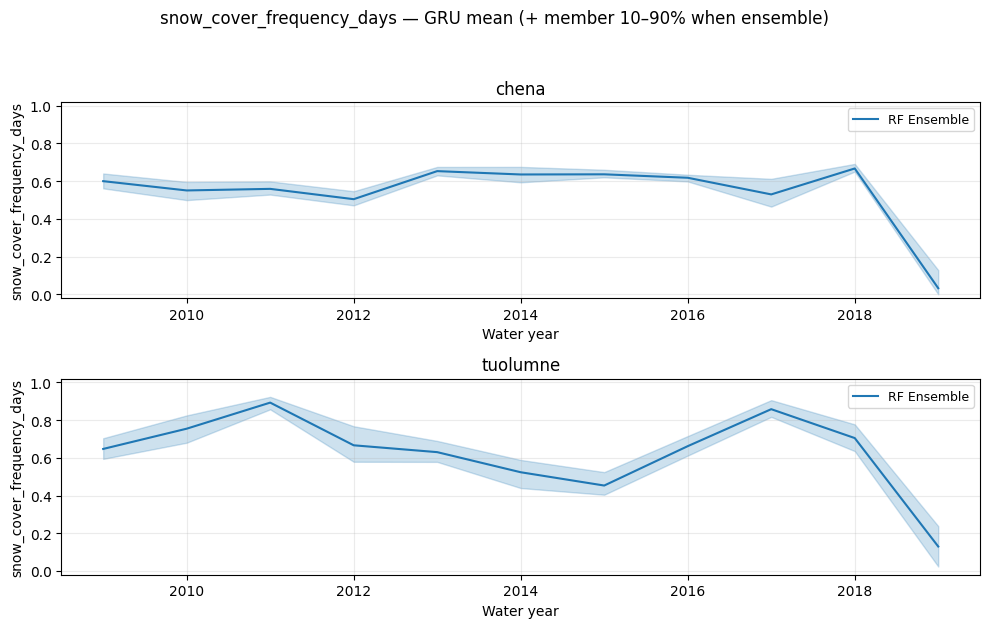

In [17]:
# Re-run this entire cell after edits so the kernel picks up the latest plotting helpers.
import matplotlib.pyplot as plt
import numpy as np


def _default_ylim_for_var(var: str, *, has_obs_csv: bool = False):
    if var == wysm.VAR_SCF_DAYS and not has_obs_csv:
        return (-0.02, 1.02)
    return None


def _resolve_plot_year_range(
    start_year: int | None,
    end_year: int | None,
) -> tuple[int | None, int | None]:
    """Apply notebook config defaults when start/end are omitted."""
    if start_year is None:
        start_year = plot_start_year
    if end_year is None:
        end_year = plot_end_year
    if start_year is not None and end_year is not None and start_year > end_year:
        raise ValueError(f"start_year ({start_year}) must be <= end_year ({end_year})")
    return start_year, end_year


def _sel_water_year_range(
    da: xr.DataArray,
    start_year: int | None,
    end_year: int | None,
) -> xr.DataArray:
    if start_year is None and end_year is None:
        return da
    if "water_year" not in da.dims:
        return da
    lo = start_year if start_year is not None else int(da["water_year"].min())
    hi = end_year if end_year is not None else int(da["water_year"].max())
    return da.sel(water_year=slice(lo, hi))


def _filter_obs_series(
    wy: np.ndarray,
    mean: np.ndarray,
    start_year: int | None,
    end_year: int | None,
) -> tuple[np.ndarray, np.ndarray]:
    wy = np.asarray(wy, dtype=int)
    mean = np.asarray(mean, dtype=float)
    mask = np.ones(wy.shape, dtype=bool)
    if start_year is not None:
        mask &= wy >= int(start_year)
    if end_year is not None:
        mask &= wy <= int(end_year)
    return wy[mask], mean[mask]


def _obs_series_for_catchment(
    catchment: str,
    var: str,
    *,
    start_year: int | None = None,
    end_year: int | None = None,
):
    if not include_obs_csv:
        return None
    csv_path = obs_csv_by_catchment.get(catchment)
    if csv_path is None:
        return None
    csv_path = Path(csv_path)
    if not csv_path.is_file():
        return None
    wy, mean = load_obs_csv_gru_mean_series(csv_path, var)
    start_year, end_year = _resolve_plot_year_range(start_year, end_year)
    return _filter_obs_series(wy, mean, start_year, end_year)


def _open_plot_datasets(path_dict: dict[str, Path], var: str) -> dict[str, xr.Dataset]:
    """Open saved NetCDFs for plotting (lazy); caller must close via ``_close_plot_datasets``."""
    opened: dict[str, xr.Dataset] = {}
    try:
        for label, path in path_dict.items():
            opened[label] = open_snow_metrics_nc(path, variables=[var])
        return opened
    except Exception:
        _close_plot_datasets(opened)
        raise


def _close_plot_datasets(datasets: dict[str, xr.Dataset]) -> None:
    for ds in datasets.values():
        ds.close()


def _color_cycle(n: int):
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(n)]


def _gru_mean_series(da: xr.DataArray) -> xr.DataArray:
    """Mean over ``gru``; keep ``water_year`` and optional ``member``."""
    if "gru" not in da.dims:
        raise ValueError(f"Expected gru dimension; got {da.dims}")
    return da.mean(dim="gru", skipna=True)


def _ensemble_stats(da_wy_member: xr.DataArray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return water years, mean line, and 10/90 percentiles (percentiles equal mean when deterministic)."""
    wy = np.asarray(da_wy_member["water_year"].values)
    arr = np.asarray(da_wy_member.values, dtype=float)
    if "member" in da_wy_member.dims:
        member_axis = da_wy_member.dims.index("member")
        mean = np.nanmean(arr, axis=member_axis)
        p10 = np.nanpercentile(arr, 10, axis=member_axis)
        p90 = np.nanpercentile(arr, 90, axis=member_axis)
    else:
        mean = arr
        p10 = arr
        p90 = arr
    return wy, mean, p10, p90


def _plot_sources_on_ax(
    ax,
    opened: dict[str, xr.Dataset],
    *,
    var: str,
    labels_ordered: list[str],
    color_cycle,
    gru_sel=None,
    ylabel: str | bool = True,
    xlabel: str | None = "Water year",
    title: str | None = None,
    ylim=None,
    start_year: int | None = None,
    end_year: int | None = None,
    obs_series=None,
    obs_label: str | None = None,
):
    start_year, end_year = _resolve_plot_year_range(start_year, end_year)

    for i, label in enumerate(labels_ordered):
        ds = opened[label]
        da = ds[var]
        if gru_sel is not None:
            da = da.sel(gru=gru_sel)
        da = _sel_water_year_range(da, start_year, end_year)
        da_m = _gru_mean_series(da)
        wy, mean, p10, p90 = _ensemble_stats(da_m)
        color = color_cycle[i % len(color_cycle)]
        if "member" in da_m.dims:
            ax.fill_between(wy, p10, p90, alpha=0.22, color=color)
        ax.plot(
            wy,
            mean,
            color=color,
            lw=1.8,
            marker="o",
            ms=4,
            markeredgecolor="white",
            markeredgewidth=0.5,
            label=label,
        )

    if obs_series is not None:
        obs_wy, obs_mean = obs_series
        ax.plot(
            obs_wy,
            obs_mean,
            color="k",
            ls="--",
            lw=2,
            marker="o",
            ms=4,
            label=obs_label or obs_csv_label,
            zorder=5,
        )

    if ylabel:
        ax.set_ylabel(ylabel if isinstance(ylabel, str) else var)
    if xlabel:
        ax.set_xlabel(xlabel)
    if title:
        ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(ylim)
    if start_year is not None or end_year is not None:
        lo = start_year if start_year is not None else None
        hi = end_year if end_year is not None else None
        if lo is not None and hi is not None:
            ax.set_xlim(lo - 0.5, hi + 0.5)
        elif lo is not None:
            ax.set_xlim(left=lo - 0.5)
        elif hi is not None:
            ax.set_xlim(right=hi + 0.5)
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.25)


def plot_metric_vs_water_year(
    output_nc=None,
    *,
    output_nc_by_catchment=None,
    var: str = wysm.VAR_SCF_DAYS,
    figsize=None,
    ylim=None,
    per_gru=False,
    catchment: str | None = None,
    start_year: int | None = None,
    end_year: int | None = None,
):
    """
    Plot a water-year snow metric vs calendar water-year label.

    Pass **either** ``output_nc`` (one catchment) **or** ``output_nc_by_catchment``.

    ``start_year`` / ``end_year`` filter the x-axis (inclusive water years).
    When omitted, uses ``plot_start_year`` / ``plot_end_year`` from the config cell.
    Set those config values to ``None`` to plot all available years.
    """
    if (output_nc is None) == (output_nc_by_catchment is None):
        raise ValueError("Pass exactly one of `output_nc` or `output_nc_by_catchment`.")

    start_year, end_year = _resolve_plot_year_range(start_year, end_year)

    if output_nc_by_catchment is not None:
        catchment_names = list(output_nc_by_catchment.keys())
        has_obs = include_obs_csv and any(
            _obs_series_for_catchment(c, var, start_year=start_year, end_year=end_year) is not None
            for c in catchment_names
        )
        if ylim is None:
            ylim = _default_ylim_for_var(var, has_obs_csv=has_obs)
        n = len(catchment_names)
        fig, axes = plt.subplots(n, 1, figsize=figsize or (10, 3.2 * n), squeeze=False)
        axes = axes.ravel()
        for ax, cat in zip(axes, catchment_names):
            path_dict = output_nc_by_catchment[cat]
            labels_ordered = list(path_dict.keys())
            opened = _open_plot_datasets(path_dict, var)
            try:
                _plot_sources_on_ax(
                    ax,
                    opened,
                    var=var,
                    labels_ordered=labels_ordered,
                    color_cycle=_color_cycle(len(labels_ordered)),
                    title=cat,
                    ylim=ylim,
                    start_year=start_year,
                    end_year=end_year,
                    obs_series=_obs_series_for_catchment(
                        cat, var, start_year=start_year, end_year=end_year
                    ),
                )
            finally:
                _close_plot_datasets(opened)
        wy_note = ""
        if start_year is not None or end_year is not None:
            wy_note = f" ({start_year or '…'}–{end_year or '…'})"
        fig.suptitle(
            f"{var} — GRU mean (+ member 10–90% when ensemble){wy_note}",
            y=0.995,
        )
        fig.tight_layout(rect=[0, 0.02, 1, 0.96])
        return fig, axes

    if not output_nc:
        raise ValueError("output_nc is empty — run processing or build_output_nc_manifest().")
    labels_ordered = list(output_nc.keys())
    obs_series = (
        _obs_series_for_catchment(catchment, var, start_year=start_year, end_year=end_year)
        if catchment
        else None
    )
    if ylim is None:
        ylim = _default_ylim_for_var(var, has_obs_csv=obs_series is not None)

    if per_gru:
        opened = _open_plot_datasets(output_nc, var)
        try:
            common = None
            for ds in opened.values():
                g = np.asarray(ds["gru"].values)
                common = g if common is None else np.intersect1d(common, g)
            out = []
            for g in common:
                fig, ax = plt.subplots(1, 1, figsize=figsize or (10, 4))
                _plot_sources_on_ax(
                    ax,
                    opened,
                    var=var,
                    labels_ordered=labels_ordered,
                    color_cycle=_color_cycle(len(labels_ordered)),
                    gru_sel=g,
                    ylim=ylim,
                    start_year=start_year,
                    end_year=end_year,
                    title=f"GRU {g}",
                    obs_series=obs_series,
                )
                fig.suptitle(f"{var} vs water year — GRU {g}", y=1.03)
                fig.tight_layout()
                out.append((g, fig, ax))
            return out
        finally:
            _close_plot_datasets(opened)

    fig, ax = plt.subplots(1, 1, figsize=figsize or (10, 4))
    opened = _open_plot_datasets(output_nc, var)
    try:
        _plot_sources_on_ax(
            ax,
            opened,
            var=var,
            labels_ordered=labels_ordered,
            color_cycle=_color_cycle(len(labels_ordered)),
            ylim=ylim,
            start_year=start_year,
            end_year=end_year,
            obs_series=obs_series,
        )
    finally:
        _close_plot_datasets(opened)
    fig.suptitle(f"{var} — GRU mean (+ member 10–90% when ensemble)", y=1.03)
    fig.tight_layout()
    return fig, ax


output_nc_by_catchment = build_output_nc_manifest()

# --- Publication figure (catchments × metrics) ---
# fig, axes = plot_snow_metrics_publication(output_nc_by_catchment)
# plt.show()

# --- Single-metric debug plots ---
# fig, axes = plot_metric_vs_water_year(
#     output_nc_by_catchment=output_nc_by_catchment,
#     var=wysm.VAR_SCF_DAYS,
# )
# plt.show()


#### Snow disappearance day (SDD) vs water year

Plots **`snow_disappearance_day_of_water_year`** (Oct 1 = 1, Sep 30 ≈ 365). Lower values indicate earlier melt-out within the water year.


/tmp/ipykernel_2382262/1457090980.py:41: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=member_axis)
/home/x-dcasson/snowda/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/tmp/ipykernel_2382262/1457090980.py:41: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=member_axis)
/home/x-dcasson/snowda/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


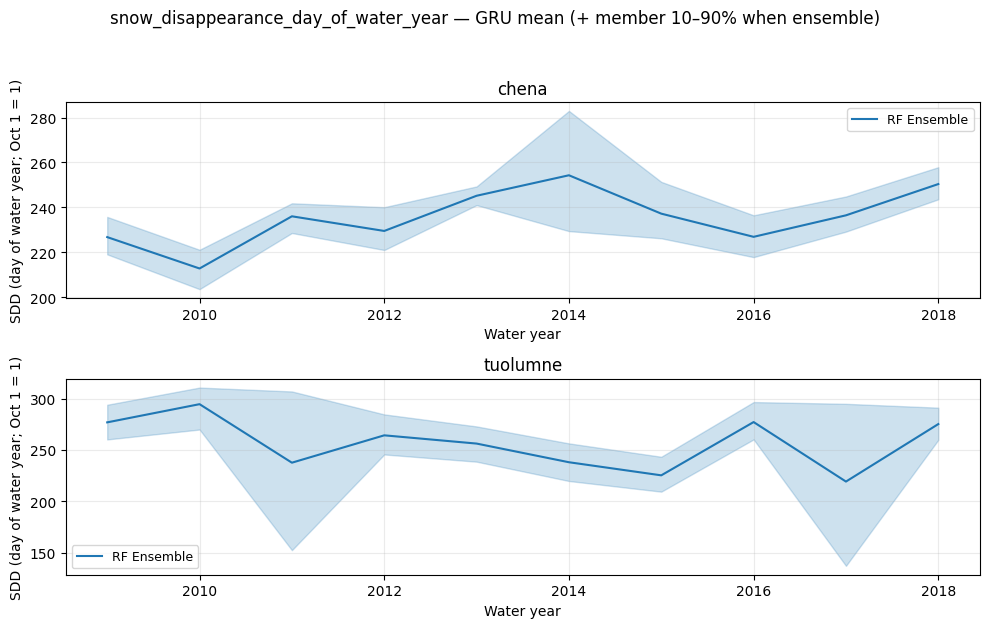

In [18]:
# Uses plot_start_year / plot_end_year from the config cell (2009–2019 by default).
# Override per call: start_year=2010, end_year=2018

fig, axes = plot_snow_metrics_publication(
    output_nc_by_catchment,
    vars=(
        wysm.VAR_SNOW_DISAPPEARANCE,
        wysm.VAR_SCF_DAYS,
    ),
    # start_year=plot_start_year,
    # end_year=plot_end_year,
)
plt.show()


#### Spatial mean maps

Maps the **water-year mean** (and **member mean** when present) of a saved NetCDF variable onto catchment HRU polygons from `{catchment}_tdx.gpkg`.

The NetCDF `gru` coordinate is joined automatically to **`HRU_ID`** or **`GRU_ID`** in the GeoPackage.


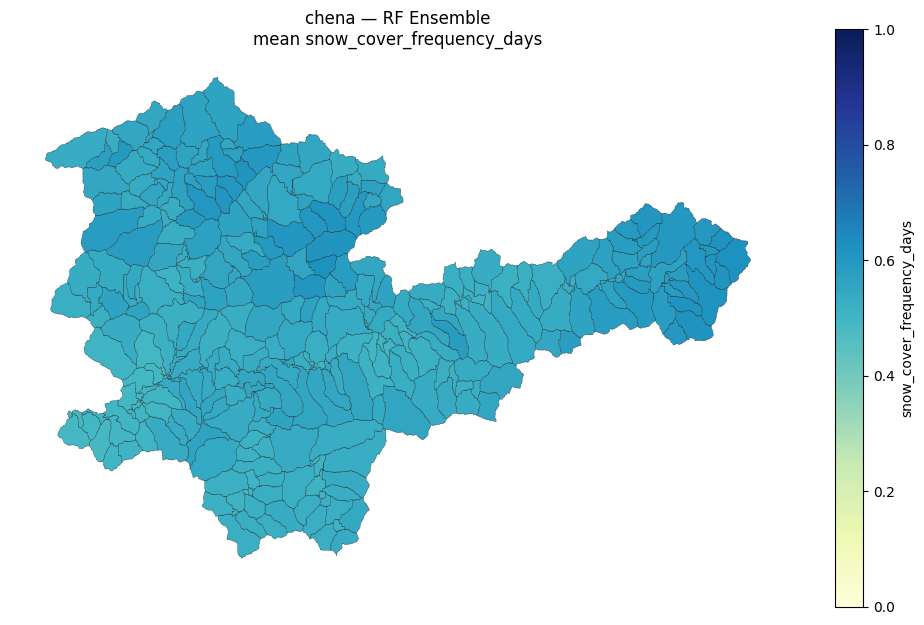

ValueError: minvalue must be less than or equal to maxvalue

ValueError: minvalue must be less than or equal to maxvalue

<Figure size 1000x800 with 2 Axes>

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def catchment_gpkg_path(catchment: str) -> Path:
    """Return the TauDEM HRU GeoPackage for a catchment."""
    return gpep_root / catchment / "gis" / f"{catchment}_tdx.gpkg"


def spatial_mean_per_gru(
    ds: xr.Dataset,
    var: str,
    *,
    reduce_dims: tuple[str, ...] | None = None,
) -> xr.DataArray:
    """Mean over water year and ensemble member (when present), one value per ``gru``."""
    if var not in ds:
        raise KeyError(f"{var!r} not in dataset; found {list(ds.data_vars)}")
    da = ds[var]
    if reduce_dims is None:
        reduce_dims = tuple(d for d in ("water_year", "member") if d in da.dims)
    if not reduce_dims:
        raise ValueError(f"{var} has no water_year/member dims to reduce: {da.dims}")
    out = da.mean(dim=reduce_dims, skipna=True)
    if "gru" not in out.dims:
        raise ValueError(f"Expected a gru dimension after reduction; got {out.dims}")
    return out


def infer_gpkg_join_field(gru_values: np.ndarray, gdf: gpd.GeoDataFrame) -> str:
    """Pick the GeoPackage column that best matches NetCDF ``gru`` values."""
    gru_values = np.asarray(gru_values, dtype=np.int64)
    candidates: list[tuple[int, str]] = []

    for field in ("HRU_ID", "GRU_ID", "gruId", "gru_id", "hruId", "hru_id"):
        if field not in gdf.columns:
            continue
        gpkg_ids = gdf[field].astype(np.int64).values
        n_match = int(np.isin(gru_values, gpkg_ids).sum())
        if n_match:
            candidates.append((n_match, field))

    if not candidates:
        raise ValueError(
            "Could not match NetCDF gru values to the GeoPackage. "
            f"gru sample={gru_values[:8].tolist()} …; gpkg columns={list(gdf.columns)}"
        )

    candidates.sort(reverse=True)
    return candidates[0][1]



def plot_spatial_mean_on_gpkg(
    nc_path: Path | str,
    *,
    catchment: str,
    var: str = wysm.VAR_SCF_DAYS,
    source_label: str | None = None,
    gpkg_path: Path | str | None = None,
    gpkg_id_field: str | None = None,
    figsize: tuple[float, float] = (10, 8),
    cmap: str = "viridis",
    vmin: float | None = None,
    vmax: float | None = None,
    edgecolor: str = "black",
    linewidth: float = 0.15,
    title: str | None = None,
    ax: plt.Axes | None = None,
):
    """
    Choropleth of the water-year (and member) mean on catchment HRU polygons.

    Reads ``nc_path`` from disk. Joins ``gru`` to ``gpkg_id_field`` when set;
    otherwise auto-detects ``HRU_ID`` vs ``GRU_ID``.
    """
    nc_path = Path(nc_path)
    gpkg_path = Path(gpkg_path) if gpkg_path is not None else catchment_gpkg_path(catchment)
    if not gpkg_path.is_file():
        raise FileNotFoundError(f"GeoPackage not found: {gpkg_path}")

    ds = open_snow_metrics_nc(nc_path, variables=[var])
    try:
        mean_da = spatial_mean_per_gru(ds, var).load()
    finally:
        ds.close()

    gdf = gpd.read_file(gpkg_path)
    join_field = gpkg_id_field or infer_gpkg_join_field(mean_da["gru"].values, gdf)
    if join_field not in gdf.columns:
        raise KeyError(f"{gpkg_path} has no {join_field!r}; columns: {list(gdf.columns)}")

    merge_df = pd.DataFrame(
        {
            join_field: np.asarray(mean_da["gru"].values, dtype=np.int64),
            "value": np.asarray(mean_da.values, dtype=float),
        }
    )

    gdf = gdf.copy()
    gdf[join_field] = gdf[join_field].astype(np.int64)
    plot_gdf = gdf.merge(merge_df, on=join_field, how="left")

    n_missing = plot_gdf["value"].isna().sum()
    if n_missing:
        print(
            f"Warning: {n_missing} of {len(plot_gdf)} polygons have no mapped value "
            f"(joined on {join_field}; {len(merge_df)} values in NetCDF)."
        )

    if var == wysm.VAR_SCF_DAYS:
        vmin = 0.0 if vmin is None else vmin
        vmax = 1.0 if vmax is None else vmax
        cmap = cmap if cmap != "viridis" else "YlGnBu"
    elif var == wysm.VAR_SNOW_DISAPPEARANCE and vmax is None:
        vmax = 200.0

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    else:
        fig = ax.figure

    plot_kw = dict(
        column="value",
        cmap=cmap,
        legend=True,
        legend_kwds={"label": var, "shrink": 0.75},
        ax=ax,
        edgecolor=edgecolor,
        linewidth=linewidth,
        missing_kwds={"color": "lightgrey", "label": "no data"},
    )
    if vmin is not None:
        plot_kw["vmin"] = vmin
    if vmax is not None:
        plot_kw["vmax"] = vmax

    plot_gdf.plot(**plot_kw)

    if title is None:
        src = f" — {source_label}" if source_label else ""
        title = f"{catchment}{src}\nmean {var}"
    ax.set_title(title)
    ax.set_axis_off()

    if created_fig:
        fig.tight_layout()
    return fig, ax, plot_gdf


def plot_spatial_mean_panel(
    output_nc_by_catchment: dict[str, dict[str, Path]],
    *,
    source_label: str = "RF Ensemble",
    var: str = wysm.VAR_SCF_DAYS,
    catchments_list: list[str] | None = None,
    ncols: int = 2,
    figsize: tuple[float, float] | None = None,
    **plot_kwargs,
):
    """One panel per catchment for a single source label (reads NetCDF paths from disk)."""
    catchments_list = catchments_list or list(output_nc_by_catchment.keys())
    n = len(catchments_list)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    if figsize is None:
        figsize = (5.5 * ncols, 5 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for i, catchment in enumerate(catchments_list):
        path_dict = output_nc_by_catchment[catchment]
        if source_label not in path_dict:
            raise KeyError(
                f"{catchment}: missing source {source_label!r}; have {list(path_dict.keys())}"
            )
        plot_spatial_mean_on_gpkg(
            path_dict[source_label],
            catchment=catchment,
            var=var,
            source_label=source_label,
            ax=axes[i],
            title=f"{catchment} — {source_label}",
            **plot_kwargs,
        )

    for j in range(i + 1, len(axes)):
        axes[j].set_axis_off()

    fig.suptitle(f"Spatial mean {var}", y=1.02)
    fig.tight_layout()
    return fig, axes


# --- Examples (edit catchment / source as needed) ---

catchment = catchments[0]
source_label = "RF Ensemble"

fig, ax, _ = plot_spatial_mean_on_gpkg(
    output_nc_by_catchment[catchment][source_label],
    catchment=catchment,
    var=wysm.VAR_SCF_DAYS,
    source_label=source_label,
)
plt.show()


# SDD map for the same source:
fig, ax, _ = plot_spatial_mean_on_gpkg(
    output_nc_by_catchment[catchment][source_label],
    catchment=catchment,
    var=wysm.VAR_SNOW_DISAPPEARANCE,
    source_label=source_label,
    cmap="plasma",
)
plt.show()

# All catchments, one source:
# fig, axes = plot_spatial_mean_panel(
#     output_nc_by_catchment,
#     source_label="RF Ensemble",
#     var=wysm.VAR_SCF_DAYS,
# )
# plt.show()


# --- Model vs CSV obs comparison (rows: RF | MOD10A1 | Difference; columns: catchments) ---
source_label = "RF Ensemble"

if include_obs_csv:
    fig, axes, panel_gdfs = plot_spatial_model_obs_panel(
        output_nc_by_catchment,
        obs_csv_by_catchment,
        model_label=source_label,
        catchments_list=catchments,
        var=wysm.VAR_SCF_DAYS,
    )
    plt.show()

    fig, axes, panel_gdfs = plot_spatial_model_obs_panel(
        output_nc_by_catchment,
        obs_csv_by_catchment,
        model_label=source_label,
        catchments_list=catchments,
        var=wysm.VAR_SNOW_DISAPPEARANCE,
    )
    plt.show()

# Single catchment, single water year (optional):
# fig, axes, cmp_gdf = plot_spatial_model_obs_comparison(
#     output_nc_by_catchment["chena"][source_label],
#     obs_csv_by_catchment["chena"],
#     catchment="chena",
#     var=wysm.VAR_SCF_DAYS,
#     water_year=2015,
#     model_label=source_label,
# )
# plt.show()
